In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

file_path = "../data/data.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")

 
print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (541909, 8)
Sütun Adları: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [2]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
df.info()
print("Dublikat sətir:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB
Dublikat sətir: 5268


In [4]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [5]:
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df_cancelled = df[df['InvoiceNo'].str.startswith('C')].copy()
df_valid = df[~df['InvoiceNo'].str.startswith('C')].copy()

print(f"Legv edilmis (cancelled) setir sayi: {df_cancelled.shape[0]}")
print(f"Legv edilmis unikal invoice sayi: {df_cancelled['InvoiceNo'].nunique()}")
print(f"Qalan (valid) setir sayi: {df_valid.shape[0]}")

Legv edilmis (cancelled) setir sayi: 9288
Legv edilmis unikal invoice sayi: 3836
Qalan (valid) setir sayi: 532621


In [6]:
neg_not_cancelled = df_valid[df_valid['Quantity'] < 0]
print(f"Legv edilmemis, lakin menfi Quantity-li setir sayi: {neg_not_cancelled.shape[0]}")
print(neg_not_cancelled[['StockCode', 'Description', 'Quantity', 'UnitPrice']].head())
print(f"\nUmumi menfi Quantity setir sayi (cancelled daxil): {(df['Quantity'] < 0).sum()}")

Legv edilmemis, lakin menfi Quantity-li setir sayi: 1336
     StockCode Description  Quantity  UnitPrice
2406     21777         NaN       -10        0.0
4347    84952C         NaN       -38        0.0
7188     22712         NaN       -20        0.0
7189     22028         NaN       -20        0.0
7190     85067         NaN        -6        0.0

Umumi menfi Quantity setir sayi (cancelled daxil): 10624


In [7]:
qty_threshold = df_valid[df_valid['Quantity'] > 0]['Quantity'].quantile(0.999)
df_cancelled_keys = df_cancelled.copy()
df_cancelled_keys['AbsQty'] = df_cancelled_keys['Quantity'].abs()
cancel_match_keys = df_cancelled_keys.groupby(
    ['CustomerID', 'StockCode', 'UnitPrice', 'AbsQty']
).size().reset_index(name='n_cancel')

df_valid['AbsQty'] = df_valid['Quantity']
outlier_candidates = df_valid[df_valid['Quantity'] > qty_threshold]
matched_outliers = outlier_candidates.merge(
    cancel_match_keys, on=['CustomerID', 'StockCode', 'UnitPrice', 'AbsQty'], how='inner'
)

print(f"Statistik ekstremal setir sayi (Qty > {qty_threshold:.0f}): {outlier_candidates.shape[0]}")
print(f"Bunlardan tam uygun legv qeydi olanlar (cixarilacaq): {matched_outliers.shape[0]}")
print(matched_outliers[['InvoiceNo', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']].head(10))

# Bu setirleri InvoiceNo +  StockCode kombinasiyasina gore df_valid-den cixaraq
bad_invoice_stock = set(zip(matched_outliers['InvoiceNo'], matched_outliers['StockCode']))
mask = df_valid.apply(lambda r: (r['InvoiceNo'], r['StockCode']) not in bad_invoice_stock, axis=1)
df_valid = df_valid[mask].drop(columns=['AbsQty'])

print(f"\nTemizlikdən sonra df_valid olcusu: {df_valid.shape}")

Statistik ekstremal setir sayi (Qty > 480): 465
Bunlardan tam uygun legv qeydi olanlar (cixarilacaq): 26
  InvoiceNo                         Description  Quantity  UnitPrice  \
0    539109  WHITE HANGING HEART T-LIGHT HOLDER       500       2.55   
1    540815  WHITE HANGING HEART T-LIGHT HOLDER      1930       2.55   
2    540815         GIN + TONIC DIET METAL SIGN      2000       1.85   
3    540815  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114       2.10   
4    540818                  DOORMAT FAIRY CAKE       670       6.75   
5    541431      MEDIUM CERAMIC TOP STORAGE JAR     74215       1.04   
6    550461  FAIRY CAKE FLANNEL ASSORTED COLOUR      3114       2.10   
7    556484                   HERB MARKER BASIL      1515       0.55   
8    558523           VINTAGE BILLBOARD TEA MUG       701       1.06   
9    558523                 SAVE THE PLANET MUG       576       1.06   

   CustomerID  
0     16013.0  
1     15749.0  
2     15749.0  
3     15749.0  
4     15749.0  
5     

In [8]:
df_clean = df_valid[(df_valid['Quantity'] > 0) & (df_valid['UnitPrice'] > 0)].copy()
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

print(f"Temiz dataset olcusu (revenue/mehsul analizi ucun): {df_clean.shape}")
print(f"Umumi gelir: £{df_clean['Revenue'].sum():,.2f}")

Temiz dataset olcusu (revenue/mehsul analizi ucun): (530078, 10)
Umumi gelir: £10,372,228.75


In [9]:
df_customer_base = df_clean.dropna(subset=['CustomerID']).copy()
print(f"CustomerID movcud olan temiz setir sayi: {df_customer_base.shape[0]}")
customer_agg = df_customer_base.groupby('CustomerID').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Orders=('InvoiceNo', 'nunique'),
).reset_index()
customer_agg['Avg_Order_Value'] = (customer_agg['Total_Revenue'] / customer_agg['Total_Orders']).round(2)
customer_agg = customer_agg.sort_values('Total_Revenue', ascending=False)
print(customer_agg.head(10))
print(f"\nOrtalama sifaris deyeri (butun musteriler uzre orta): £{customer_agg['Avg_Order_Value'].mean():.2f}")

CustomerID movcud olan temiz setir sayi: 397858
      CustomerID  Total_Revenue  Total_Orders  Avg_Order_Value
1688     14646.0      280206.02            73          3838.44
4200     18102.0      259657.30            60          4327.62
3727     17450.0      190725.43            46          4146.20
1878     14911.0      143825.06           201           715.55
54       12415.0      124914.53            21          5948.31
1332     14156.0      117379.63            55          2134.18
3770     17511.0       91062.38            31          2937.50
2701     16029.0       67255.56            63          1067.55
3175     16684.0       66653.56            28          2380.48
1288     14096.0       65164.79            17          3833.22

Ortalama sifaris deyeri (butun musteriler uzre orta): £380.59


In [11]:
country_agg = df_clean.groupby('Country').agg(
    Total_Revenue=('Revenue', 'sum'),
    Order_Count=('InvoiceNo', 'nunique'),
).sort_values('Total_Revenue', ascending=False)
country_agg['Revenue_Share_%'] = (country_agg['Total_Revenue'] / country_agg['Total_Revenue'].sum() * 100).round(2)
print(country_agg.head(10))

                Total_Revenue  Order_Count  Revenue_Share_%
Country                                                    
United Kingdom    8730766.294        18015            84.17
Netherlands        285446.340           94             2.75
EIRE               283453.960          288             2.73
Germany            228867.140          457             2.21
France             209715.110          392             2.02
Australia          138521.310           57             1.34
Spain               61577.110           90             0.59
Switzerland         57089.900           54             0.55
Belgium             41196.340           98             0.40
Sweden              38378.330           36             0.37


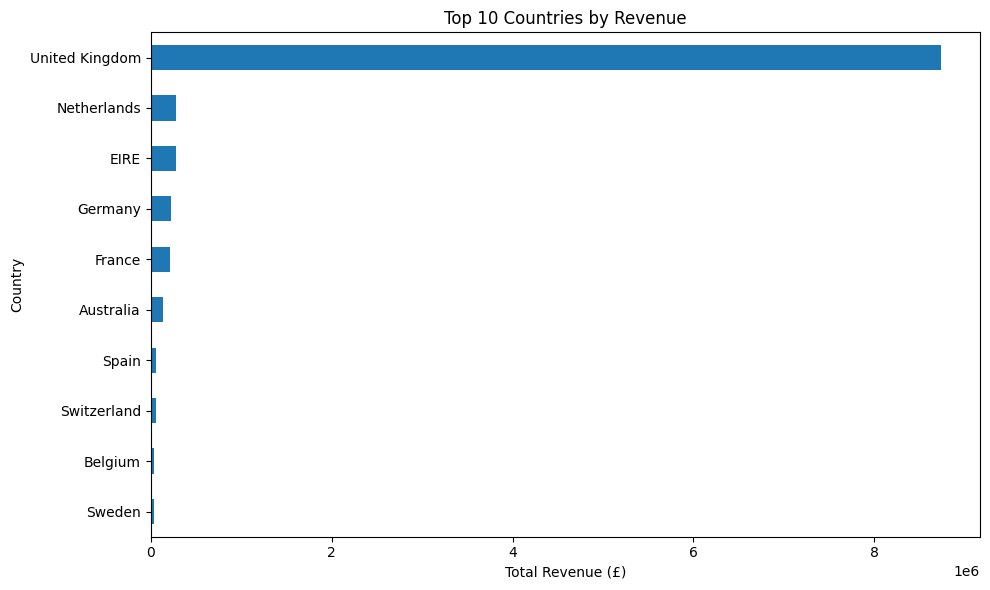

In [12]:
top10_countries = country_agg.head(10)

plt.figure(figsize=(10, 6))
top10_countries['Total_Revenue'].sort_values().plot(kind='barh', color='#1f77b4')
plt.xlabel('Total Revenue (£)')
plt.title('Top 10 Countries by Revenue')
plt.tight_layout()
plt.show()

In [13]:
monthly_revenue = df_clean.groupby('YearMonth')['Revenue'].sum()
peak_month = monthly_revenue.idxmax()
print(f"En yuksek gelir ayi: {peak_month} (£{monthly_revenue.max():,.2f})")
print(monthly_revenue)

En yuksek gelir ayi: 2011-11 (£1,509,496.33)
YearMonth
2010-12     822471.140
2011-01     594497.560
2011-02     523631.890
2011-03     717639.360
2011-04     531269.221
2011-05     770536.020
2011-06     758675.350
2011-07     719221.191
2011-08     759138.380
2011-09    1054764.812
2011-10    1140564.420
2011-11    1509496.330
2011-12     470323.080
Freq: M, Name: Revenue, dtype: float64


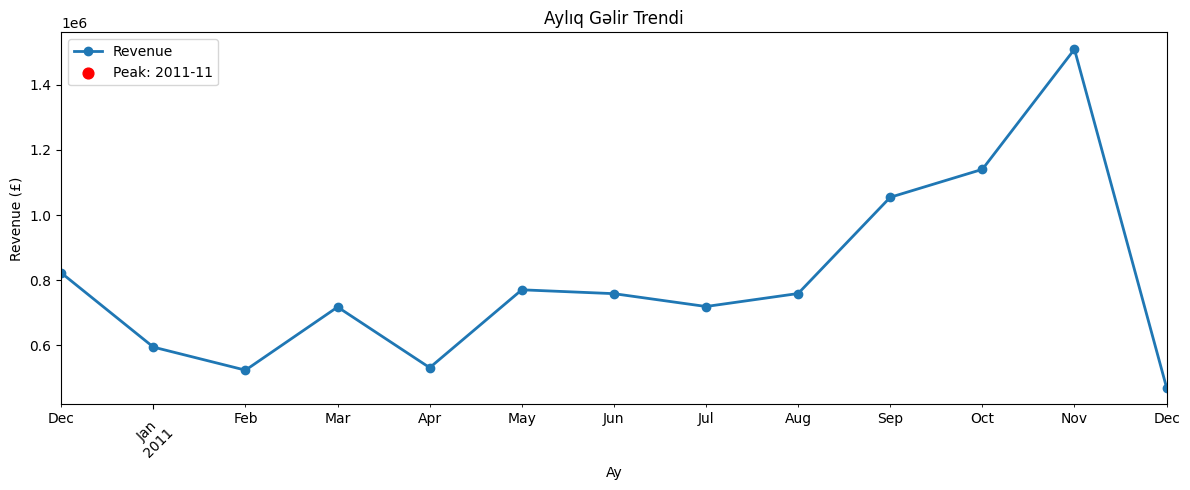

In [14]:
plt.figure(figsize=(12, 5))
monthly_revenue.plot(marker='o', linewidth=2, color='#1f77b4')
plt.scatter([monthly_revenue.index.get_loc(peak_month)], [monthly_revenue.max()],
            color='red', zorder=5, s=60, label=f'Peak: {peak_month}')
plt.xlabel('Ay')
plt.ylabel('Revenue (£)')
plt.title('Aylıq Gəlir Trendi')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
top20_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)
print(top20_products)

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     55047
JUMBO BAG RED RETROSPOT               48474
POPCORN HOLDER                        36761
ASSORTED COLOUR BIRD ORNAMENT         36461
PACK OF 72 RETROSPOT CAKE CASES       36419
WHITE HANGING HEART T-LIGHT HOLDER    35461
RABBIT NIGHT LIGHT                    30788
MINI PAINT SET VINTAGE                26633
PACK OF 12 LONDON TISSUES             26135
PACK OF 60 PINK PAISLEY CAKE CASES    24854
VICTORIAN GLASS HANGING T-LIGHT       24304
ASSORTED COLOURS SILK FAN             23826
BROCADE RING PURSE                    23056
RED  HARMONICA IN BOX                 21933
JUMBO BAG PINK POLKADOT               21465
SMALL POPCORN HOLDER                  20160
PAPER CHAIN KIT 50'S CHRISTMAS        19355
LUNCH BAG RED RETROSPOT               19353
PARTY BUNTING                         18295
60 TEATIME FAIRY CAKE CASES           18214
Name: Quantity, dtype: int64


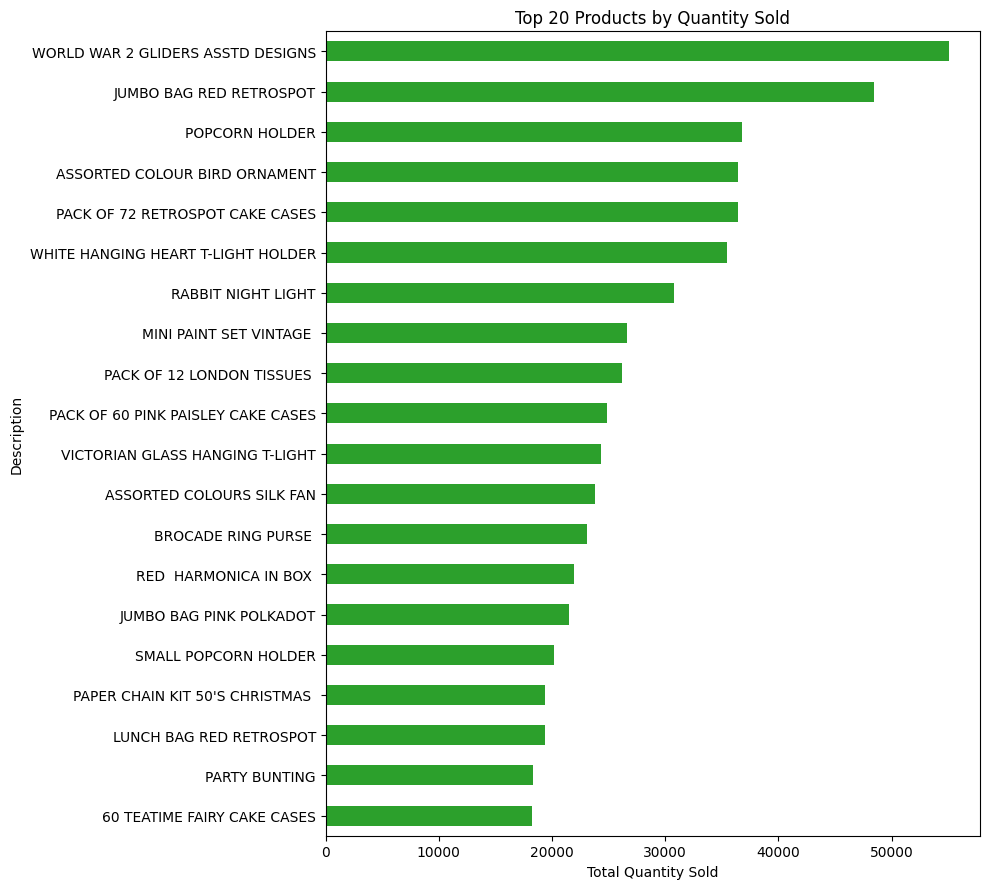

In [16]:
plt.figure(figsize=(10, 9))
top20_products.sort_values().plot(kind='barh', color='#2ca02c')
plt.xlabel('Total Quantity Sold')
plt.title('Top 20 Products by Quantity Sold')
plt.tight_layout()
plt.show()

In [17]:
total_invoices_by_country = df.groupby('Country')['InvoiceNo'].nunique()
cancelled_invoices_by_country = df_cancelled.groupby('Country')['InvoiceNo'].nunique()
return_rate = (cancelled_invoices_by_country / total_invoices_by_country * 100).fillna(0).round(2)
return_rate_df = pd.DataFrame({
    'Total_Invoices': total_invoices_by_country,
    'Cancelled_Invoices': cancelled_invoices_by_country.fillna(0).astype(int),
    'Return_Rate_%': return_rate
}).sort_values('Return_Rate_%', ascending=False)

# Yalniz kifayet qeder sifarisi olan olkeleri gosterek 
return_rate_df_filtered = return_rate_df[return_rate_df['Total_Invoices'] >= 20]
print(return_rate_df_filtered.head(15))

HIGH_RETURN_THRESHOLD = 6.0
high_return_markets = return_rate_df_filtered[return_rate_df_filtered['Return_Rate_%'] > HIGH_RETURN_THRESHOLD]
print(f"\nYuksek-return bazarlar (>{HIGH_RETURN_THRESHOLD}%, min 20 sifaris):")
print(high_return_markets['Return_Rate_%'])

                 Total_Invoices  Cancelled_Invoices  Return_Rate_%
Country                                                           
Japan                        28                 9.0          32.14
Italy                        55                17.0          30.91
Switzerland                  74                20.0          27.03
Germany                     603               146.0          24.21
Sweden                       46                10.0          21.74
Channel Islands              33                 7.0          21.21
Poland                       24                 5.0          20.83
Cyprus                       20                 4.0          20.00
EIRE                        360                72.0          20.00
Portugal                     71                13.0          18.31
Belgium                     119                21.0          17.65
Australia                    69                12.0          17.39
France                      461                69.0          1

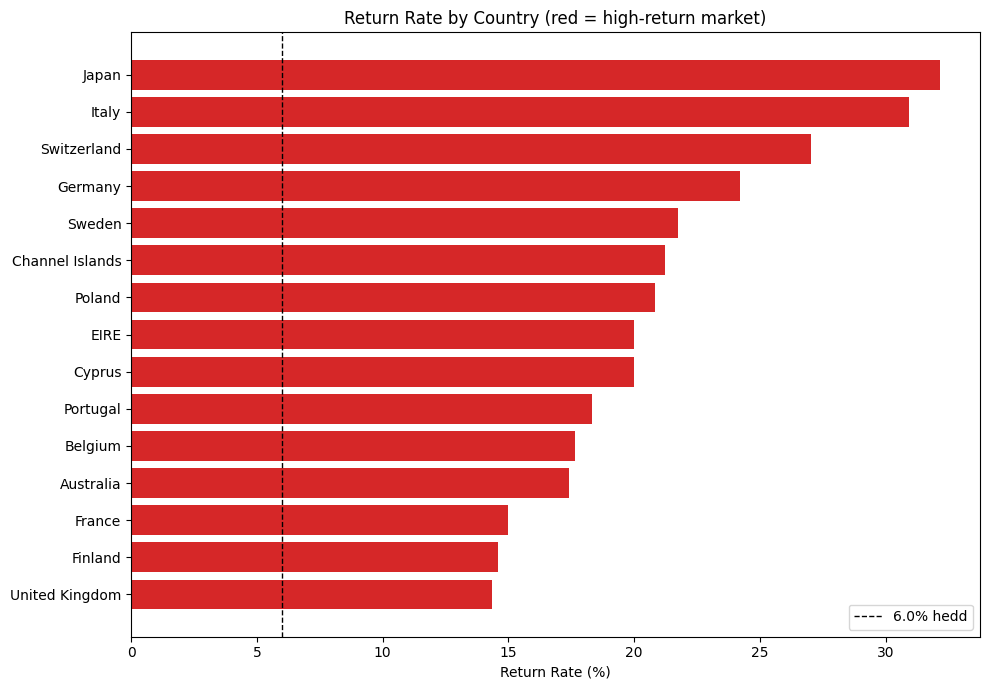

In [18]:
plt.figure(figsize=(10, 7))
plot_data = return_rate_df_filtered.head(15).sort_values('Return_Rate_%')
colors = ['#d62728' if r > HIGH_RETURN_THRESHOLD else '#1f77b4' for r in plot_data['Return_Rate_%']]
plt.barh(plot_data.index, plot_data['Return_Rate_%'], color=colors)
plt.axvline(HIGH_RETURN_THRESHOLD, color='black', linestyle='--', linewidth=1, label=f'{HIGH_RETURN_THRESHOLD}% hedd')
plt.xlabel('Return Rate (%)')
plt.title('Return Rate by Country (red = high-return market)')
plt.legend()
plt.tight_layout()
plt.show()

Top 10 musterinin umumi gelirdeki payi: 16.33%


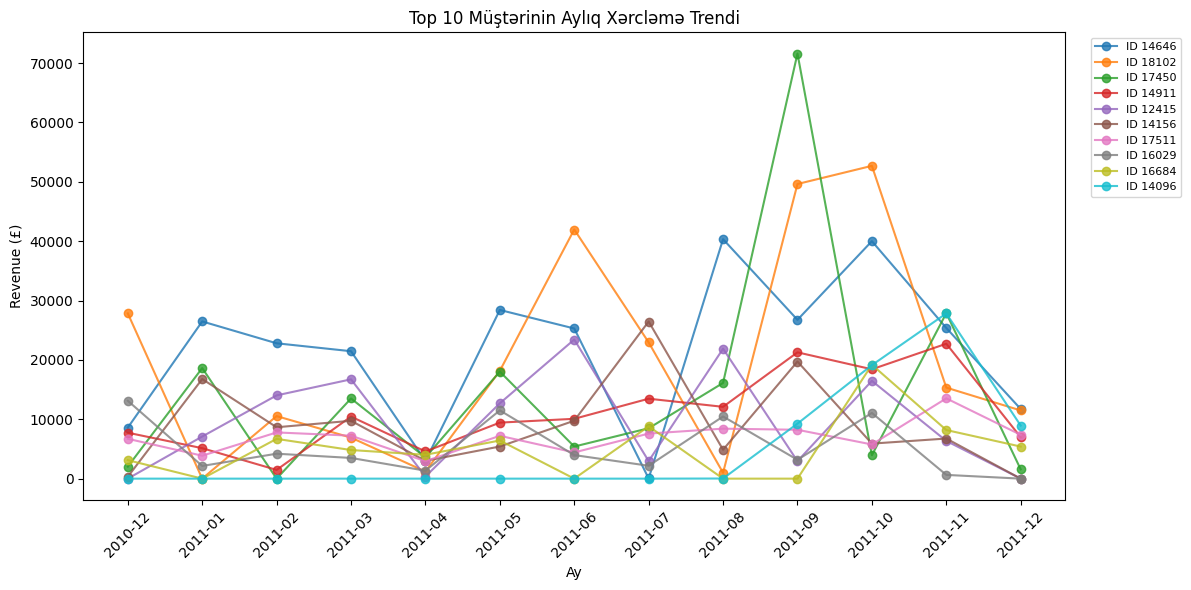

In [19]:
top10_customer_ids = customer_agg.head(10)['CustomerID'].tolist()
top10_share = customer_agg.head(10)['Total_Revenue'].sum() / customer_agg['Total_Revenue'].sum() * 100
print(f"Top 10 musterinin umumi gelirdeki payi: {top10_share:.2f}%")
top10_monthly = df_customer_base[df_customer_base['CustomerID'].isin(top10_customer_ids)].copy()
top10_pivot = top10_monthly.groupby(['YearMonth', 'CustomerID'])['Revenue'].sum().unstack(fill_value=0)
plt.figure(figsize=(12, 6))
for cust_id in top10_customer_ids:
    if cust_id in top10_pivot.columns:
        plt.plot(top10_pivot.index.astype(str), top10_pivot[cust_id], marker='o', label=f'ID {int(cust_id)}', alpha=0.8)
plt.xlabel('Ay')
plt.ylabel('Revenue (£)')
plt.title('Top 10 Müştərinin Aylıq Xərcləmə Trendi')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [20]:
basket_size = df_clean.groupby(['Country', 'InvoiceNo'])['StockCode'].nunique().reset_index(name='Unique_Products')
basket_size_by_country = basket_size.groupby('Country')['Unique_Products'].mean().sort_values(ascending=False).round(2)
print("Top 10 olke - orta basket size ")
print(basket_size_by_country.head(10))

Top 10 olke - orta basket size 
Country
RSA            57.00
Lebanon        45.00
Cyprus         37.44
Israel         36.38
Switzerland    36.02
USA            35.80
Unspecified    33.31
Brazil         32.00
Singapore      31.14
Norway         29.69
Name: Unique_Products, dtype: float64
